In [17]:
import os
import sys
from sklearn.dummy import DummyClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.model_utils import (
    load_encoded_splits,
    evaluate_classifier,
    plot_metric_scorecards,
    get_confusion_matrix_df,
    plot_roc_curve,
    run_random_search
)

In [18]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 103), y_train: (60876,)
X_val:   (13045, 103), y_val:   (13045,)
X_test:  (13046, 103), y_test:  (13046,)


In [19]:
SEED = 42

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

param_distributions = {
        'classifier__C': np.logspace(-3, 2, 20)
    }

In [20]:
search = run_random_search(
    estimator=pipeline,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_rf = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'classifier__C': np.float64(29.763514416313193)}
Best CV f1: 0.5890


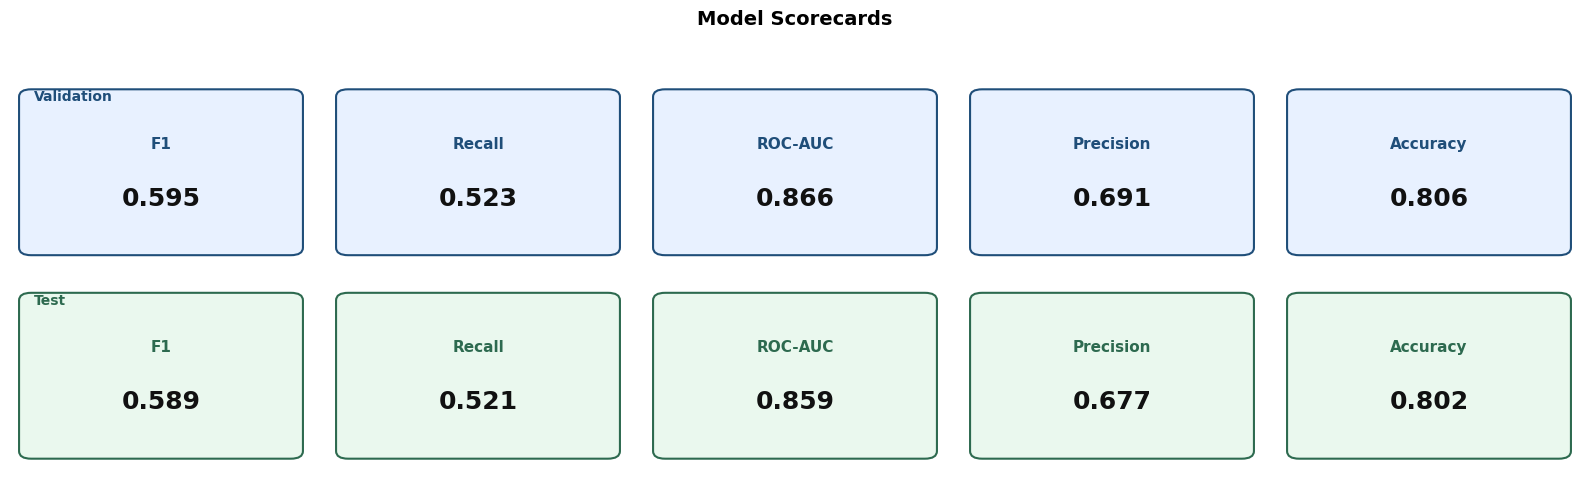

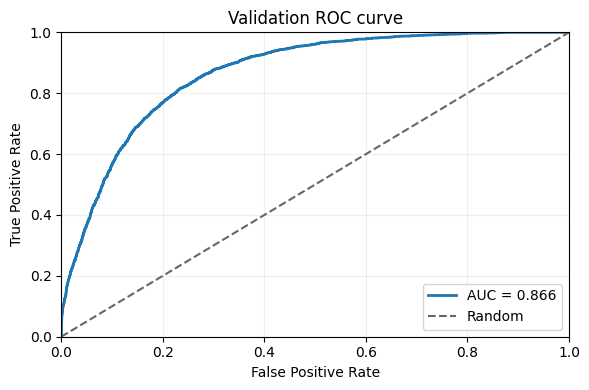

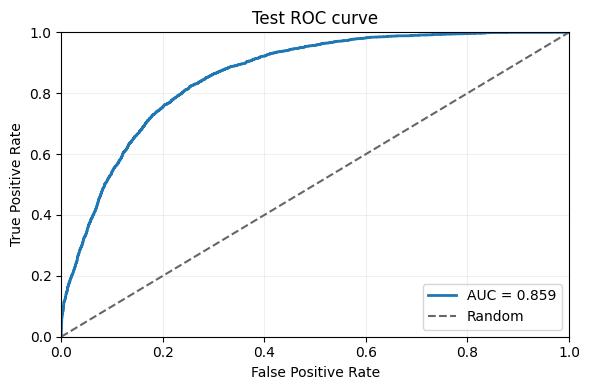

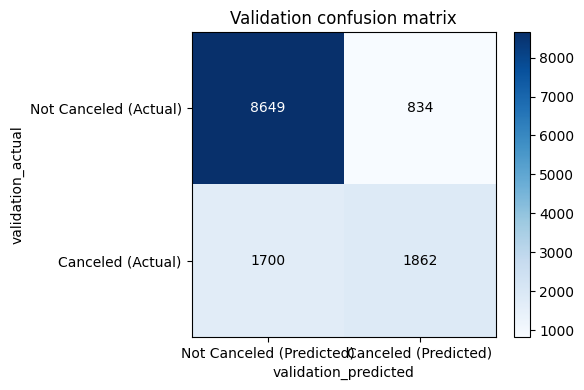

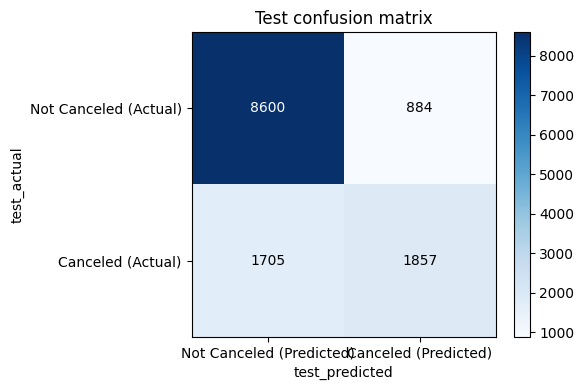

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.8057,0.6907,0.5227,0.5951,0.8661
1,test,0.8015,0.6775,0.5213,0.5892,0.8594


In [21]:
val_results = evaluate_classifier(best_rf, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_rf, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results)
plot_roc_curve(best_rf, X_val, y_val, 'validation')
plot_roc_curve(best_rf, X_test, y_test, 'test')
val_cm = get_confusion_matrix_df(best_rf, X_val, y_val, 'validation', plot=True)
test_cm = get_confusion_matrix_df(best_rf, X_test, y_test, 'test', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [22]:
classifier = best_rf.named_steps['classifier'] # type: ignore

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(classifier.coef_[0]),
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
14,required_car_parking_spaces,4.470746
15,total_of_special_requests,0.649112
31,country_PRT,0.618764
85,assigned_room_type_A,0.515698
9,previous_cancellations,0.487244
0,lead_time,0.481331
76,reserved_room_type_A,0.455754
19,agent_9,0.440212
91,assigned_room_type_G,0.377547
20,agent_240,0.351926
